In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [7]:
import pandas as pd

df = pd.read_excel("cricket_runs_dataset.csv.xlsx")
df.head()

,Match,Batsman,Batting_Team,Bowling_Team,Venue,Over,Wickets,Current_Run_Rate,Powerplay,Runs
0,1,Rohit Sharma,MI,CSK,Wankhede,5,1,8.2,Yes,45
1,2,Virat Kohli,RCB,MI,Chinnaswamy,10,2,7.8,No,68
2,3,KL Rahul,LSG,RR,Lucknow,8,1,8.5,No,55
3,4,Shubman Gill,GT,PBKS,Ahmedabad,14,3,9.2,No,82
4,5,David Warner,DC,KKR,Delhi,6,1,9.1,Yes,50


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Match             50 non-null     int64  
 1   Batsman           50 non-null     str    
 2   Batting_Team      50 non-null     str    
 3   Bowling_Team      50 non-null     str    
 4   Venue             50 non-null     str    
 5   Over              50 non-null     int64  
 6   Wickets           50 non-null     int64  
 7   Current_Run_Rate  50 non-null     float64
 8   Powerplay         50 non-null     str    
 9   Runs              50 non-null     int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 5.3 KB


In [9]:
df.describe()

,Match,Over,Wickets,Current_Run_Rate,Runs
count,50.00000,50.000000,50.000000,50.00000,50.000000
mean,25.50000,12.540000,2.840000,9.29600,67.980000
std,14.57738,4.006169,1.489555,1.06387,14.746138
min,1.00000,5.000000,0.000000,7.60000,38.000000
25%,13.25000,9.250000,2.000000,8.50000,57.250000
50%,25.50000,13.000000,2.500000,9.15000,67.500000
75%,37.75000,16.000000,4.000000,10.10000,77.750000
max,50.00000,19.000000,6.000000,11.40000,98.000000


In [10]:
df.shape

(50, 10)

In [11]:
df.columns

Index(['Match', 'Batsman', 'Batting_Team', 'Bowling_Team', 'Venue', 'Over',
       'Wickets', 'Current_Run_Rate', 'Powerplay', 'Runs'],
      dtype='str')

In [12]:
df.isnull().sum()

Match               0
Batsman             0
Batting_Team        0
Bowling_Team        0
Venue               0
Over                0
Wickets             0
Current_Run_Rate    0
Powerplay           0
Runs                0
dtype: int64

In [13]:
df = df.dropna()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop_duplicates()

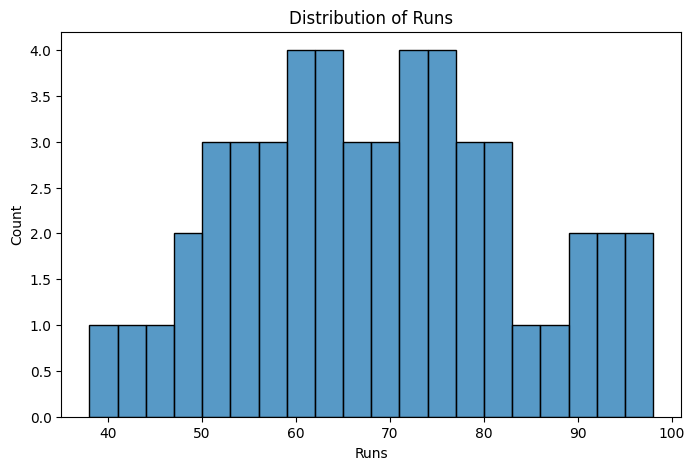

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["Runs"], bins=20)
plt.title("Distribution of Runs")
plt.show()

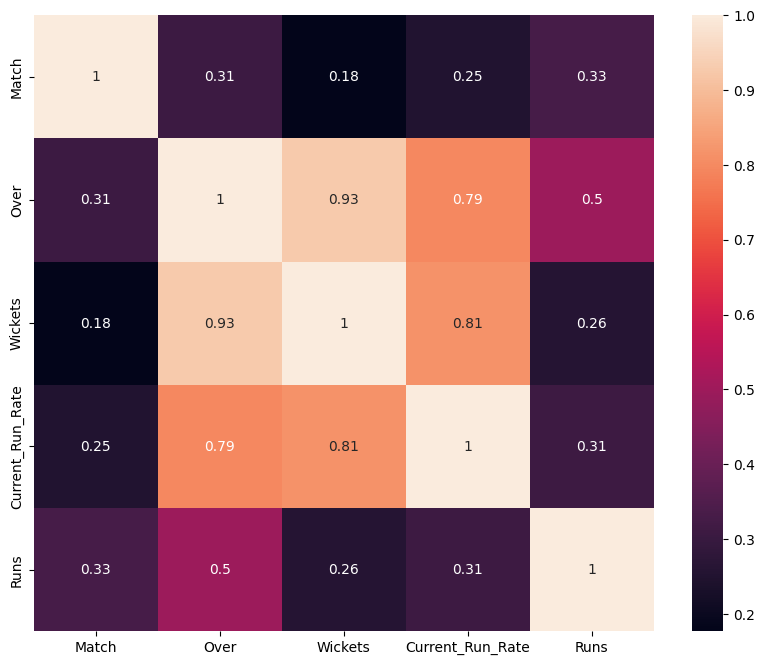

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

<Axes: xlabel='Runs'>

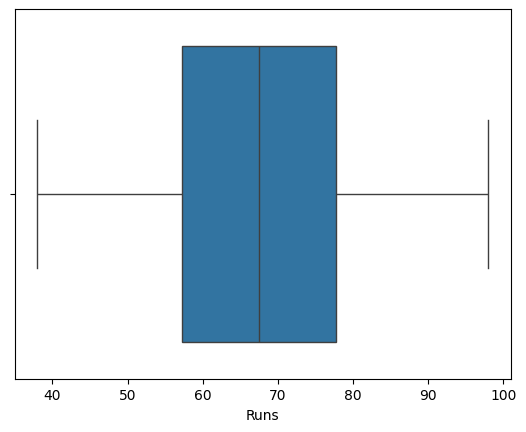

In [18]:
sns.boxplot(x=df["Runs"])

In [19]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
encoder = LabelEncoder()

# Encode each categorical column
for col in ['Batsman', 'Batting_Team', 'Bowling_Team', 'Venue', 'Powerplay']:
    df[col] = encoder.fit_transform(df[col])

# Display the first few rows
df.head()

,Match,Batsman,Batting_Team,Bowling_Team,Venue,Over,Wickets,Current_Run_Rate,Powerplay,Runs
0,1,12,5,0,11,5,1,8.2,1,45
1,2,18,6,5,3,10,2,7.8,0,68
2,3,8,4,8,8,8,1,8.5,0,55
3,4,16,2,6,0,14,3,9.2,0,82
4,5,2,1,3,4,6,1,9.1,1,50


In [20]:
X = df.drop("Runs", axis=1)
y = df["Runs"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
X = df.drop("Runs", axis=1)
y = df["Runs"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (50, 9)
Target Shape: (50,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (40, 9)
Testing Data: (10, 9)


In [24]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [25]:
lr_pred = lr.predict(X_test)

print(lr_pred)

[66.13887572 81.7707165  63.81625412 87.33774737 56.97837419 68.50607882
 58.59359079 69.94227238 62.4176986  62.25305269]


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

MAE : 8.185666885002457
MSE : 91.79789457724334
RMSE: 9.581121780733367
R2 Score: 0.47269863531941325


In [27]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [28]:
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("MSE :", mean_squared_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score:", r2_score(y_test, dt_pred))

MAE : 7.4
MSE : 71.2
RMSE: 8.438009243891594
R2 Score: 0.5910161410764547


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [30]:
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

MAE : 5.932
MSE : 53.67294
RMSE: 7.326181815925674
R2 Score: 0.6916942960537653


In [31]:
results = {
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
}

comparison = pd.DataFrame(results)
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,8.185667,9.581122,0.472699
1,Decision Tree,7.400000,8.438009,0.591016
2,Random Forest,5.932000,7.326182,0.691694


In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
5,Over,0.333599
1,Batsman,0.329249
2,Batting_Team,0.102472
7,Current_Run_Rate,0.098494
0,Match,0.049716
6,Wickets,0.032427
4,Venue,0.028891
3,Bowling_Team,0.017415
8,Powerplay,0.007736


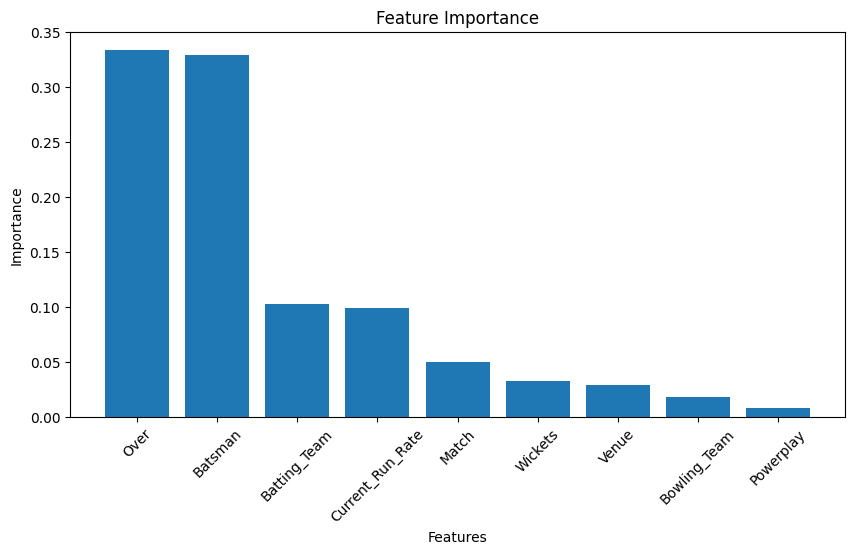

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [34]:
import joblib

joblib.dump(rf, "cricket_runs_prediction_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [35]:
print(X.columns)

Index(['Match', 'Batsman', 'Batting_Team', 'Bowling_Team', 'Venue', 'Over',
       'Wickets', 'Current_Run_Rate', 'Powerplay'],
      dtype='str')


In [36]:
import joblib

model = joblib.load("cricket_runs_prediction_model.pkl")

In [37]:
print(X.columns)

Index(['Match', 'Batsman', 'Batting_Team', 'Bowling_Team', 'Venue', 'Over',
       'Wickets', 'Current_Run_Rate', 'Powerplay'],
      dtype='str')


In [38]:
sample = pd.DataFrame({
    "Match": [101],
    "Batsman": [15],
    "Batting_Team": [2],
    "Bowling_Team": [3],
    "Venue": [1],
    "Over": [10],
    "Wickets": [2],
    "Current_Run_Rate": [8.4],
    "Powerplay": [1]
})

prediction = model.predict(sample)

print("Predicted Runs:", prediction[0])

Predicted Runs: 64.45


In [39]:
comparison = pd.DataFrame({
    "Actual Runs": y_test.values,
    "Predicted Runs": rf_pred
})

comparison.head(10)

,Actual Runs,Predicted Runs
0,48,55.55
1,69,65.00
2,64,69.54
3,92,75.54
4,52,55.23
5,78,74.19
6,67,59.31
7,81,72.49
8,53,55.36
9,65,64.83


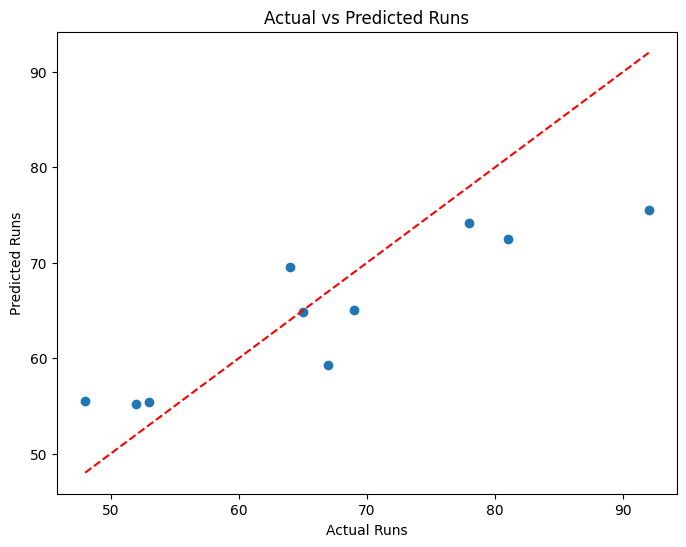

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Runs")
plt.ylabel("Predicted Runs")
plt.title("Actual vs Predicted Runs")

plt.show()

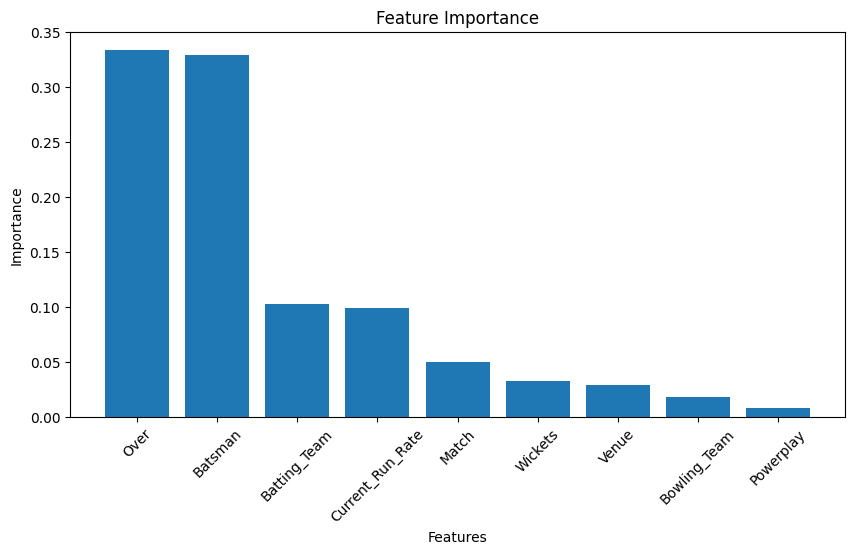

In [41]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

In [42]:
import os
print(os.getcwd())

C:\Users\mruda


In [43]:
import os
os.listdir()

['.arduinoIDE',
 '.bash_history',
 '.cache',
 '.config',
 '.copilot',
 '.eclipse',
 '.gemini',
 '.gitconfig',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.java',
 '.jupyter',
 '.lesshst',
 '.m2',
 '.matplotlib',
 '.ms-ad',
 '.neo-browser',
 '.node_repl_history',
 '.p2',
 '.packettracer',
 '.streamlit',
 '.sts4',
 '.viminfo',
 '.VirtualBox',
 '.vscode',
 '.vscode-shared',
 '1.IBM Data science professional Cer.txt',
 'abc.py',
 'AppData',
 'Application Data',
 'BasicDocument.java',
 'Cisco Packet Tracer 8.2.2',
 'Contacts',
 'Cookies',
 'cricket_runs_dataset.csv.xlsx',
 'cricket_runs_prediction_model.pkl',
 'CrossDevice',
 'Datascience.ipynb',
 'DBMS',
 'Desktop',
 'Documents',
 'Downloads',
 'eclipse',
 'eclipse-workspace',
 'eclipse-workspace1.0',
 'EfficientDocument.java',
 'Favorites',
 'insem 1.html',
 'Links',
 'Local Settings',
 'mcino-Introduction-to-Git-and-GitHub',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{2